# Análisis de lenguaje natural de reseñas de Yelp

Este notebook transforma las reseñas en representaciones analizables y estudia la relación entre el lenguaje utilizado y la valoración otorgada. El recorrido va desde la conservación de señales del texto original hasta representaciones léxicas, sentimiento, similitud, tópicos y aspectos de negocio.

La prioridad del preprocesamiento es conservar información útil para interpretar el sentimiento: negaciones, intensificadores, mayúsculas, signos de puntuación y emojis. Las transformaciones más agresivas se reservan para las representaciones léxicas, mientras que el análisis VADER se ejecuta sobre el texto original.

El objetivo es exploratorio: las asociaciones encontradas orientan el análisis y la selección de variables, pero no deben interpretarse automáticamente como relaciones causales.

In [9]:
import re
import html
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.decomposition import NMF

In [10]:
yelp_df = pd.read_csv("data/Yelp Restaurant Reviews_clean.csv", parse_dates=["Date"])
yelp_df

,Yelp URL,Rating,Date,Review Text,Name,n_chars,n_words,year,month,dow,is_negative,is_positive,rid,bucket_words,periodo
0,https://www.yelp.com/biz/sidney-dairy-barn-sidney,5,2022-01-22,All I can say is they have very good ice cream...,Sidney Dairy Barn Sidney,123,26,2022,2022-01-01,5,False,True,R045,26–50,3_post
1,https://www.yelp.com/biz/sidney-dairy-barn-sidney,4,2022-06-26,Nice little local place for ice cream.My favor...,Sidney Dairy Barn Sidney,290,50,2022,2022-06-01,6,False,True,R045,26–50,3_post
2,https://www.yelp.com/biz/sidney-dairy-barn-sidney,5,2021-08-07,A delicious treat on a hot day! Staff was very...,Sidney Dairy Barn Sidney,131,26,2021,2021-08-01,5,False,True,R045,26–50,3_post
3,https://www.yelp.com/biz/sidney-dairy-barn-sidney,4,2016-07-28,This was great service and a fun crew! I got t...,Sidney Dairy Barn Sidney,374,72,2016,2016-07-01,3,False,True,R045,51–100,1_pre_2020
4,https://www.yelp.com/biz/sidney-dairy-barn-sidney,5,2015-06-23,This is one of my favorite places to get ice c...,Sidney Dairy Barn Sidney,848,172,2015,2015-06-01,1,False,True,R045,151–200,1_pre_2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19889,https://www.yelp.com/biz/la-pasticceria-las-vegas,4,2021-07-17,Had the chocolate cannoli! The filling was ric...,La Pasticceria Las Vegas,120,21,2021,2021-07-01,5,False,True,R047,1–25,3_post
19890,https://www.yelp.com/biz/la-pasticceria-las-vegas,4,2019-10-21,Love apricot croissant! I bought it at 4:00 PM...,La Pasticceria Las Vegas,352,69,2019,2019-10-01,0,False,True,R047,51–100,1_pre_2020
19891,https://www.yelp.com/biz/la-pasticceria-las-vegas,4,2019-10-12,Line was about 25 people long. It went fast! T...,La Pasticceria Las Vegas,356,61,2019,2019-10-01,5,False,True,R047,51–100,1_pre_2020
19892,https://www.yelp.com/biz/la-pasticceria-las-vegas,5,2021-04-11,Its hard not to order everything when I come h...,La Pasticceria Las Vegas,168,31,2021,2021-04-01,6,False,True,R047,26–50,2_pandemia


## 1. Preprocesamiento

El texto se prepara para dos usos distintos. Por un lado, se conservan señales del texto original que pueden expresar intensidad o polaridad, como mayúsculas, signos repetidos y emojis. Por otro, se genera una versión normalizada para comparar palabras y construir representaciones numéricas.

In [11]:
EMOJI_MAP = {
    "😊": " emo_pos ", "😃": " emo_pos ", "😍": " emo_pos ", "👍": " emo_pos ",
    "❤️": " emo_pos ", "🔥": " emo_pos ", "😋": " emo_pos ", "🙌": " emo_pos ",
    "😞": " emo_neg ", "😡": " emo_neg ", "👎": " emo_neg ", "😢": " emo_neg ",
    "🤢": " emo_neg ", "😠": " emo_neg ",
}
 
CONTRACTIONS = {
    "won't": "will not", "can't": "cannot", "n't": " not",
    "'re": " are", "'s": " is", "'d": " would", "'ll": " will",
    "'t": " not", "'ve": " have", "'m": " am",
}
 
def contar_features_previas(texto: str) -> dict:
    """Señales que se pierden si se limpia primero. Se calculan sobre el texto crudo."""
    if not isinstance(texto, str) or not texto:
        return dict(pct_mayus=0.0, n_exclam=0, n_interrog=0, n_emoji_pos=0,
                    n_emoji_neg=0, n_signos_repetidos=0)
    letras = [c for c in texto if c.isalpha()]
    pct_mayus = (sum(c.isupper() for c in letras) / len(letras)) if letras else 0.0
    return dict(
        pct_mayus=pct_mayus,
        n_exclam=texto.count("!"),
        n_interrog=texto.count("?"),
        n_emoji_pos=sum(texto.count(e) for e in EMOJI_MAP if "pos" in EMOJI_MAP[e]),
        n_emoji_neg=sum(texto.count(e) for e in EMOJI_MAP if "neg" in EMOJI_MAP[e]),
        n_signos_repetidos=len(re.findall(r"([!?.])\1{1,}", texto)),
    )
 
feat_previas = yelp_df["Review Text"].apply(contar_features_previas).apply(pd.Series)
yelp_df = pd.concat([yelp_df, feat_previas.add_prefix("raw_")], axis=1)
 
def normalizar(texto: str) -> str:
    """Pipeline de limpieza para representaciones léxicas (BoW/TF-IDF).
    Para transformers NO se aplica esto: se usa el tokenizador propio del modelo."""
    if not isinstance(texto, str):
        return ""
    t = html.unescape(texto)
    t = re.sub(r"http\S+|www\.\S+", " ", t)                    # URLs
    t = re.sub(r"\S+@\S+", " ", t)                              # emails
    for emo, tag in EMOJI_MAP.items():
        t = t.replace(emo, tag)
    t = t.lower()
    for k, v in CONTRACTIONS.items():                           # expandir contracciones
        t = t.replace(k, v)
    t = re.sub(r"(.)\1{2,}", r"\1\1", t)                        # sooooo -> soo (alargamientos)
    t = re.sub(r"[^a-záéíóúñü\s]", " ", t)                      # fuera dígitos/puntuación
    t = re.sub(r"\s+", " ", t).strip()
    return t
 
yelp_df["texto_limpio"] = yelp_df["Review Text"].map(normalizar)

### Tokenización y stopwords

La tokenización convierte cada reseña limpia en una secuencia de palabras que puede analizarse estadísticamente. Se eliminan términos muy frecuentes y poco informativos, pero se mantiene un conjunto de negadores e intensificadores porque cambian profundamente el significado de una expresión: `not good` no equivale a `good`, y `very good` añade intensidad.

Si se eliminan demasiado pronto estas palabras, se pierde información para distinguir reseñas positivas de negativas. Por esa razón, la validación posterior incluye comprobar si el tratamiento del texto crea reseñas vacías, reduce demasiado la longitud de los textos o empobrece el vocabulario disponible para las representaciones vectoriales.

In [12]:
# --- Stopwords curadas: NO se eliminan negadores ni intensificadores ---
# Las listas por defecto de sklearn/NLTK borran 'not','no','never','very','but'.
# Eso destruye exactamente la señal que distingue "not good" de "good".
STOPWORDS_BASE = set("""a about after again all am an and any are as at be been being both
by can did do does doing down during each few for from further had has have having he her
here hers herself him himself his how i if in into is it its itself just me more most my
myself of off on once only or other our ours ourselves out own s same she should so some
such t than that the their theirs them themselves then there these they this those through
to too under until up we were what when where which while who whom why will with you your
yours yourself yourselves""".split())

NEGADORES_E_INTENSIFICADORES = {
    "not", "no", "nor", "never", "n't", "very", "too", "but", "however",
    "although", "against", "cannot", "isn", "wasn", "weren", "don", "didn",
    "doesn", "won", "wouldn", "couldn", "shouldn", "hardly", "barely",
}
STOPWORDS = STOPWORDS_BASE - NEGADORES_E_INTENSIFICADORES
 
def tokenizar(texto: str) -> list:
    return [w for w in texto.split() if w not in STOPWORDS and len(w) > 1]
 
yelp_df["tokens"] = yelp_df["texto_limpio"].map(tokenizar)
yelp_df["n_tokens"] = yelp_df["tokens"].map(len)
 

### Diagnóstico de la limpieza

Este control compara la longitud de las reseñas antes y después del preprocesamiento. La diferencia cuantifica cuánto texto se descarta por ruido, stopwords y normalización, y ayuda a detectar si la limpieza está eliminando información valiosa.

El número de reseñas vacías es una señal clave de pérdida de información. El tamaño del vocabulario orienta la complejidad de las representaciones y el coste computacional de los modelos posteriores. En conjunto, estas comprobaciones sirven para validar que la etapa de preparación del texto mantiene la señal útil sin provocar un desgaste excesivo del corpus.

In [13]:
# --- Diagnóstico del preprocesamiento ---
print(f"Longitud media ANTES de limpiar: {yelp_df['Review Text'].str.split().str.len().mean():.1f} palabras")
print(f"Longitud media DESPUÉS de limpiar+stopwords: {yelp_df['n_tokens'].mean():.1f} tokens")
vacios = (yelp_df["n_tokens"] == 0).sum()
print(f"Reseñas que quedaron vacías tras limpiar: {vacios} ({vacios/len(yelp_df):.2%})")
 
vocab_size = len(set(w for toks in yelp_df["tokens"] for w in toks))
print(f"Tamaño de vocabulario (tokens únicos): {vocab_size:,}")
 
ejemplo = yelp_df.iloc[0]
print(f"\nEjemplo — crudo:\n  {ejemplo['Review Text'][:150]}")
print(f"Ejemplo — limpio:\n  {ejemplo['texto_limpio'][:150]}")

Longitud media ANTES de limpiar: 91.4 palabras
Longitud media DESPUÉS de limpiar+stopwords: 51.0 tokens
Reseñas que quedaron vacías tras limpiar: 0 (0.00%)
Tamaño de vocabulario (tokens únicos): 21,430

Ejemplo — crudo:
  All I can say is they have very good ice cream I would for sure recommend their cookies and creme ice cream it is very good
Ejemplo — limpio:
  all i can say is they have very good ice cream i would for sure recommend their cookies and creme ice cream it is very good


## 2. Representación numérica del texto

Los modelos de aprendizaje automático no trabajan directamente con frases, por lo que cada reseña se convierte en un vector numérico. El corpus analizado aquí es la colección de textos en `texto_limpio`: cada fila representa una reseña y cada columna una característica lingüística. El resultado se mantiene como una matriz dispersa porque cada reseña contiene solo una pequeña parte del vocabulario total.

Se construyen varias representaciones porque cada una conserva una señal diferente:

- **BoW:** contabiliza cuántas veces aparece cada palabra. Es una referencia simple y interpretable, pero ignora el orden y la relación entre palabras.
- **TF-IDF:** pondera cada término según su relevancia dentro de la reseña y su rareza en el conjunto. Las palabras muy frecuentes reciben menos peso y los términos distintivos aumentan su impacto.
- **TF-IDF con unigramas y bigramas:** incorpora pares consecutivos de palabras para conservar expresiones cuyo significado cambia según el contexto, como `not worth` o `never again`.
- **N-gramas de caracteres:** fragmenta las palabras en secuencias de 3 a 5 caracteres, lo que resulta útil para capturar erratas, variaciones ortográficas y palabras ligeramente distintas.

Los filtros de frecuencia cumplen una función de control del vocabulario. `min_df=5` elimina palabras que aparecen en muy pocas reseñas y probablemente no generalizan bien; `max_df=0.9` excluye términos presentes en la mayoría de textos, ya que aportan poca discriminación. En las representaciones con bigramas y en los n-gramas de caracteres se fija además un máximo de características para evitar matrices desproporcionadas o excesivamente costosas.

La forma (`shape`) de cada matriz permite comprobar cuántas reseñas y variables se generan. En BoW, la densidad indica qué proporción de celdas contiene un valor distinto de cero; una densidad baja es esperable y explica por qué conviene usar matrices dispersas.

Los términos con mayor suma TF-IDF y los bigramas más frecuentes sirven como exploración del vocabulario dominante. No son automáticamente las palabras más importantes para predecir el rating, pero ayudan a entender el contenido del corpus y detectar expresiones relevantes antes de modelar.

Los embeddings preentrenados no se ejecutan en esta etapa porque requieren pesos externos. Este notebook deja preparada la comparación de representaciones léxicas y marca el punto donde se podrían incorporar representaciones semánticas si se dispone de modelos descargados o almacenados localmente.

BoW           -> shape (19894, 7304), densidad 0.5599%
TF-IDF (1)     -> shape (19894, 7304)
TF-IDF (1,2)   -> shape (19894, 34783)
Char n-gram    -> shape (19894, 30000)

Términos con mayor masa TF-IDF en el corpus:
was          944.7
cream        829.3
ice          815.8
not          769.7
but          669.9
place        595.3
good         549.4
great        487.7
very         418.9
like         410.6
delicious    403.0
love         399.6
flavors      398.2
get          393.3
best         390.2
one          389.4
chocolate    376.4
go           373.3
try          371.6
would        370.7

Bigramas más frecuentes:
ice cream           15706
was not              2424
but not              1448
soft serve           1433
cream was            1307
was good             1203
was very             1115
but was              1099
salted caramel        913
peanut butter         911
red velvet            839
cereal milk           831
best ice              794
customer service      792
good but     

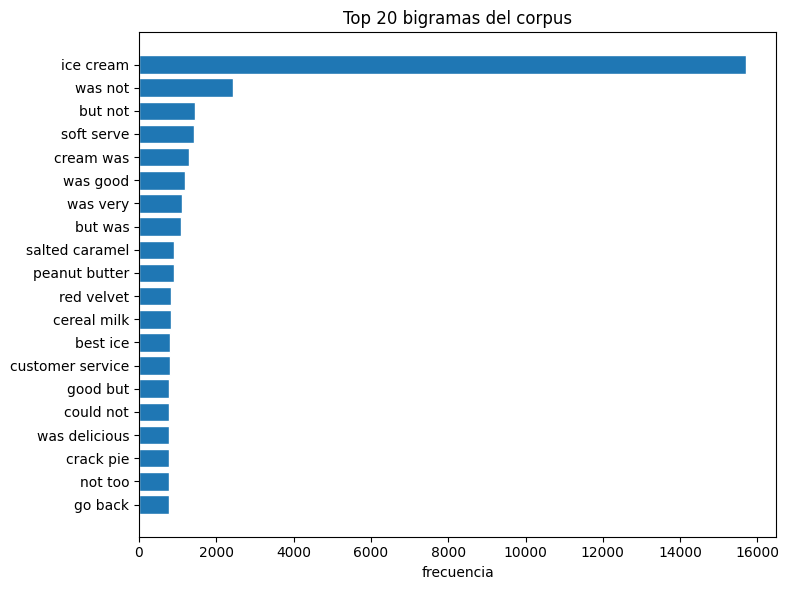

In [14]:
CORPUS = yelp_df["texto_limpio"].values
 
# --- BoW: piso de la escalera ---
bow_vec = CountVectorizer(min_df=5, max_df=0.9, stop_words=list(STOPWORDS))
X_bow = bow_vec.fit_transform(CORPUS)
print(f"BoW           -> shape {X_bow.shape}, densidad {X_bow.nnz / np.prod(X_bow.shape):.4%}")
 
# --- TF-IDF unigrama ---
tfidf_vec = TfidfVectorizer(min_df=5, max_df=0.9, stop_words=list(STOPWORDS),
                             sublinear_tf=True)
X_tfidf = tfidf_vec.fit_transform(CORPUS)
print(f"TF-IDF (1)     -> shape {X_tfidf.shape}")
 
# --- TF-IDF con bigramas: donde vive la negación ('not worth', 'never again') ---
tfidf_ngram_vec = TfidfVectorizer(min_df=5, max_df=0.9, stop_words=list(STOPWORDS),
                                   ngram_range=(1, 2), sublinear_tf=True, max_features=50_000)
X_tfidf_ngram = tfidf_ngram_vec.fit_transform(CORPUS)
print(f"TF-IDF (1,2)   -> shape {X_tfidf_ngram.shape}")
 
# --- N-gramas de caracteres: robusto a typos y variantes ortográficas ---
char_vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5),
                            min_df=5, max_features=30_000, sublinear_tf=True)
X_char = char_vec.fit_transform(CORPUS)
print(f"Char n-gram    -> shape {X_char.shape}")
 
# --- Términos con mayor peso TF-IDF global (diagnóstico, no un ranking serio) ---
suma_tfidf = np.asarray(X_tfidf.sum(axis=0)).ravel()
top_terms = pd.Series(suma_tfidf, index=tfidf_vec.get_feature_names_out()).nlargest(20)
print("\nTérminos con mayor masa TF-IDF en el corpus:")
print(top_terms.round(1).to_string())
 
# --- Bigramas más frecuentes tras filtrar stopwords (ojo con negación) ---
bigram_vec = CountVectorizer(ngram_range=(2, 2), min_df=10, stop_words=list(STOPWORDS))
X_bigram = bigram_vec.fit_transform(CORPUS)
top_bigramas = pd.Series(np.asarray(X_bigram.sum(axis=0)).ravel(),
                          index=bigram_vec.get_feature_names_out()).nlargest(20)
print("\nBigramas más frecuentes:")
print(top_bigramas.to_string())
 
fig, ax = plt.subplots(figsize=(8, 6))
tb = top_bigramas.sort_values()
ax.barh(tb.index, tb.values, edgecolor="white")
ax.set_title("Top 20 bigramas del corpus")
ax.set_xlabel("frecuencia")
plt.tight_layout(); plt.show()

## 3. Sentimiento y relación con el rating

VADER se aplica sobre el texto original porque utiliza señales que desaparecen al limpiar: mayúsculas, puntuación, emojis y expresiones intensivas. El resultado resume la orientación del texto en una escala continua y se agrupa en tres categorías para compararlo con las estrellas.

Las estadísticas por rating permiten observar si las reseñas con distintas puntuaciones también difieren en longitud, uso de mayúsculas, exclamaciones y sentimiento léxico. Esta comparación es descriptiva: muestra patrones asociados al rating, pero no implica que una señal concreta sea la causa de la valoración ni que un modelo basado en una sola variable tenga capacidad explicativa suficiente.

            n  palabras_media  palabras_mediana  pct_mayus  exclamaciones  vader_medio
Rating                                                                                
1        1217          56.240              42.0      0.035          1.104       -0.025
2        1280          62.468              50.0      0.033          0.768        0.322
3        2069          62.849              50.0      0.032          0.716        0.625
4        4446          58.005              46.0      0.035          1.382        0.836
5       10882          43.937              32.0      0.040          2.094        0.874


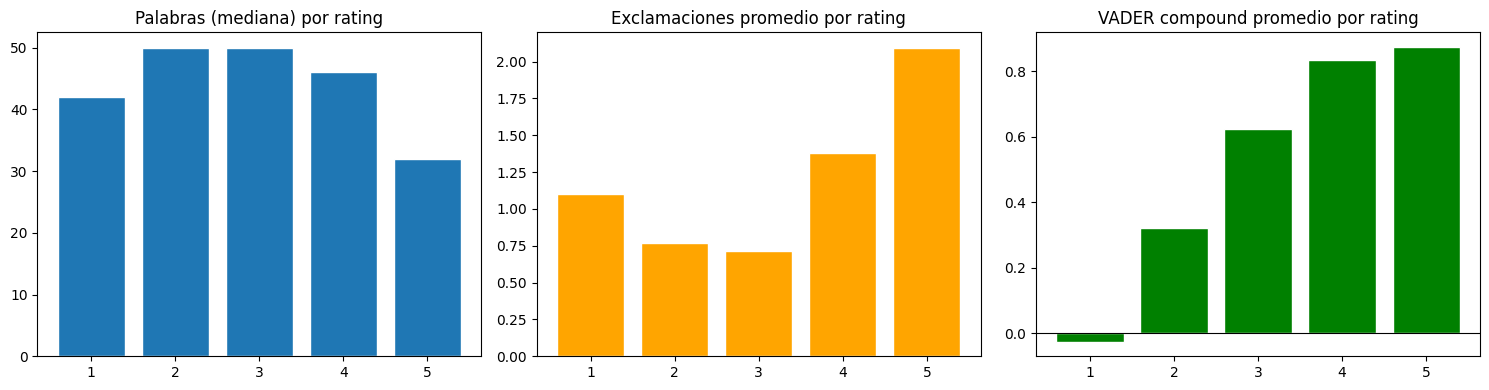

In [15]:
sia = SentimentIntensityAnalyzer()
 
def vader_compound(texto):
    if not isinstance(texto, str) or not texto:
        return 0.0
    return sia.polarity_scores(texto)["compound"]
 
# VADER se corre sobre el texto CRUDO (usa mayúsculas y puntuación como señal),
# no sobre texto_limpio, que ya perdió esa información a propósito.
yelp_df["vader"] = yelp_df["Review Text"].map(vader_compound)
yelp_df["vader_clase"] = pd.cut(yelp_df["vader"], bins=[-1.01, -0.05, 0.05, 1.01],
                                 labels=["negativo", "neutro", "positivo"])
 
# --- Estadísticas básicas por rating ---
stats = yelp_df.groupby("Rating").agg(
    n=("Rating", "size"),
    palabras_media=("n_tokens", "mean"),
    palabras_mediana=("n_tokens", "median"),
    pct_mayus=("raw_pct_mayus", "mean"),
    exclamaciones=("raw_n_exclam", "mean"),
    vader_medio=("vader", "mean"),
).round(3)
print(stats.to_string())
 
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].bar(stats.index.astype(str), stats["palabras_mediana"], edgecolor="white")
ax[0].set_title("Palabras (mediana) por rating")
 
ax[1].bar(stats.index.astype(str), stats["exclamaciones"], edgecolor="white", color="orange")
ax[1].set_title("Exclamaciones promedio por rating")
 
ax[2].bar(stats.index.astype(str), stats["vader_medio"], edgecolor="white", color="green")
ax[2].axhline(0, color="black", lw=.8)
ax[2].set_title("VADER compound promedio por rating")
plt.tight_layout(); plt.show()

### Comparación entre sentimiento y estrellas

Se contrasta la polaridad estimada por VADER con una versión agrupada de las estrellas: bajas (1-2), media (3) y altas (4-5). La tabla permite distinguir coincidencias, desacuerdos moderados y casos en los que el texto parece positivo pero la puntuación es baja, o al contrario.

El porcentaje de acuerdo resume hasta qué punto una regla léxica sencilla recupera la orientación de las estrellas. Los desacuerdos fuertes sirven como señal de complejidad: pueden deberse a ironía, contexto, opiniones mixtas, aspectos concretos del servicio o limitaciones del diccionario. Por eso no deben interpretarse como un límite matemático del rendimiento de cualquier modelo; son una referencia del ruido que deja este método.

Los ejemplos finales son útiles para una revisión cualitativa y para detectar errores sistemáticos del análisis automático.

In [16]:
# Se agrupan las estrellas para comparar la orientación general del texto.
def rating_esperado_por_vader(v):
    if v <= -0.05: return "baja (1-2)"
    if v >= 0.05: return "alta (4-5)"
    return "media (3)"

def bucket_rating(r):
    if r <= 2: return "baja (1-2)"
    if r >= 4: return "alta (4-5)"
    return "media (3)"

yelp_df["rating_bucket"] = yelp_df["Rating"].map(bucket_rating)
yelp_df["vader_bucket"] = yelp_df["vader"].map(rating_esperado_por_vader)

# La tabla mide asociación entre la señal léxica y el rating, no causalidad.
discrepancia = pd.crosstab(yelp_df["rating_bucket"], yelp_df["vader_bucket"], normalize="all") * 100
print("\nMatriz rating real vs. sentimiento VADER (% del total):")
print(discrepancia.round(1).to_string())

# El acuerdo sirve como referencia del comportamiento de una regla sencilla.
tasa_acuerdo = (yelp_df["rating_bucket"] == yelp_df["vader_bucket"]).mean()
tasa_desacuerdo_fuerte = ((yelp_df["rating_bucket"] == "baja (1-2)") &
                           (yelp_df["vader_bucket"] == "alta (4-5)")).mean() + \
                          ((yelp_df["rating_bucket"] == "alta (4-5)") &
                           (yelp_df["vader_bucket"] == "baja (1-2)")).mean()
print(f"\nAcuerdo rating vs. VADER (bucketizado): {tasa_acuerdo:.1%}")
print(f"Desacuerdo FUERTE (polos opuestos): {tasa_desacuerdo_fuerte:.1%}")
print("→ Este desacuerdo fuerte es piso de ruido irreducible aproximado:\n"
      "  ni un modelo perfecto debería esperar superar mucho ese margen\n"
      "  usando solo el texto, salvo que capture matices que VADER no ve.\n")

# Los ejemplos permiten investigar por qué la regla contradice la valoración.
casos_raros = yelp_df[(yelp_df["rating_bucket"] == "baja (1-2)") &
                       (yelp_df["vader_bucket"] == "alta (4-5)")]
print(f"Ejemplos de {len(casos_raros)} reseñas con 1-2★ pero texto detectado como positivo:")
for _, r in casos_raros.head(3).iterrows():
    print(f"  [{r['rid']}, {int(r['Rating'])}★, vader={r['vader']:.2f}] {r['Review Text'][:140]}")


Matriz rating real vs. sentimiento VADER (% del total):
vader_bucket   alta (4-5)  baja (1-2)  media (3)
rating_bucket                                   
alta (4-5)           75.2         1.4        0.5
baja (1-2)            7.2         5.0        0.3
media (3)             8.9         1.3        0.2

Acuerdo rating vs. VADER (bucketizado): 80.3%
Desacuerdo FUERTE (polos opuestos): 8.6%
→ Este desacuerdo fuerte es piso de ruido irreducible aproximado:
  ni un modelo perfecto debería esperar superar mucho ese margen
  usando solo el texto, salvo que capture matices que VADER no ve.

Ejemplos de 1440 reseñas con 1-2★ pero texto detectado como positivo:
  [R045, 2★, vader=0.38] Went here for the 1st time tonight. I ordered a turtle tornado. It was excellent. TONS of pecans and lots of flavor. I guess I could be pick
  [R045, 2★, vader=0.34] Ice cream is good but the service could be improved. I rarely get what I actually order. A peanut butter cup tornado with chocolate ice crea
  [R022, 

## 4. Similitud entre reseñas

La similitud del coseno compara reseñas a partir de sus representaciones TF-IDF. El primer análisis busca pares casi idénticos en una muestra y puede revelar textos copiados o plantillas repetidas. Se utilizan n-gramas de caracteres porque capturan semejanzas incluso cuando hay pequeñas diferencias de escritura.

El cálculo se limita a 4.000 reseñas por coste computacional. Por tanto, encontrar pares similares es una señal para inspeccionar; no encontrarlos en la muestra no demuestra que no existan en el conjunto completo.

El segundo análisis toma una reseña negativa como referencia y recupera textos con vocabulario parecido. La similitud indica cercanía temática o léxica, no necesariamente que las reseñas hablen del mismo restaurante ni que tengan la misma valoración.

In [17]:
# %%
# ============================================================
# 4. SIMILITUD — duplicados/near-duplicates vs. exploración temática
# ============================================================
 
# --- 4a. Duplicados / near-duplicates: es limpieza, retroalimenta la sección 1 ---
# Con TF-IDF de char n-gramas porque es robusto a reordenamientos y typos,
# y computacionalmente factible por lotes con un umbral alto de similitud.
muestra_n = min(4000, len(yelp_df))       # coseno par-a-par es O(n²); se limita
idx_muestra = yelp_df.sample(muestra_n, random_state=42).index
X_dup = char_vec.transform(yelp_df.loc[idx_muestra, "texto_limpio"])
 
sim = cosine_similarity(X_dup)
np.fill_diagonal(sim, 0)
umbral = 0.92
pares_i, pares_j = np.where(sim > umbral)
pares = [(i, j) for i, j in zip(pares_i, pares_j) if i < j]
 
print(f"Pares con similitud > {umbral} en muestra de {muestra_n}: {len(pares)}")
if pares:
    idx_arr = idx_muestra.to_numpy()
    filas = []
    for i, j in pares[:10]:
        a, b = idx_arr[i], idx_arr[j]
        filas.append((yelp_df.loc[a, "rid"], yelp_df.loc[b, "rid"], round(sim[i, j], 3)))
    print(pd.DataFrame(filas, columns=["rid_a", "rid_b", "similitud"]).to_string(index=False))
    print("→ Si rid_a != rid_b, es posible reseña copiada/spam entre negocios.\n"
          "  Si rid_a == rid_b, son reseñas casi idénticas del mismo negocio\n"
          "  (revisar si son plantillas del dueño respondiendo, o el mismo\n"
          "  cliente reseñando dos veces).")
else:
    print("Sin near-duplicates por encima del umbral en la muestra.")

Pares con similitud > 0.92 en muestra de 4000: 0
Sin near-duplicates por encima del umbral en la muestra.


### Exploración temática por similitud

Este bloque toma una reseña de referencia y compara su vocabulario con el resto del corpus mediante similitud coseno sobre una matriz TF-IDF con unigramas y bigramas. La idea es recuperar reseñas con un lenguaje parecido, incluso si no comparten restaurante, fecha ni valoración exacta.

La comparación es útil para detectar patrones temáticos recurrentes: por ejemplo, opiniones de servicio lento, comida insatisfactoria o ambiente incómodo pueden agruparse aunque aparezcan en distintos negocios. El resultado no equivale a una clasificación ni a una prueba causal; simplemente indica cercanía léxica y ayuda a identificar ejemplos relevantes para revisión manual.

El análisis interpretativo se centra en preguntar qué tienen en común estas reseñas. Si la referencia y sus vecinos comparten términos de experiencia, mala atención o retrasos, eso sugiere un tema dominante del corpus; si el vocabulario se parece pero las estrellas difieren, entonces la discrepancia probablemente viene de matices de expresión más que de contenido puro.

In [18]:
# --- Exploración temática: documentos similares a un caso de referencia ---
# Con TF-IDF de palabras + bigramas, que captura tema mejor que char n-gram.
def documentos_similares(idx_ref, X, top_k=5):
    sims = cosine_similarity(X[idx_ref], X).ravel()
    top = np.argsort(-sims)[1:top_k + 1]        # excluye el propio documento
    return top, sims[top]
 
idx_ref = yelp_df.index.get_loc(yelp_df[yelp_df["is_negative"]].index[0]) \
    if "is_negative" in yelp_df.columns else 0
vecinos, sims_val = documentos_similares(idx_ref, X_tfidf_ngram)
 
print(f"\nReseña de referencia [{yelp_df.iloc[idx_ref]['rid']}, "
      f"{yelp_df.iloc[idx_ref]['Rating']}★]:")
print(f"  {yelp_df.iloc[idx_ref]['Review Text'][:150]}")
print("\nReseñas más similares (mismo tema/vocabulario, no necesariamente mismo negocio):")
for pos, s in zip(vecinos, sims_val):
    r = yelp_df.iloc[pos]
    print(f"  [{r['rid']}, {r['Rating']}★, sim={s:.3f}] {r['Review Text'][:120]}")


Reseña de referencia [R045, 1★]:
  The soft-serve is way too sweet and has a strange Splenda-like aftertaste. The flavors tasted very artificial, and I ended up with a stomach ache when

Reseñas más similares (mismo tema/vocabulario, no necesariamente mismo negocio):
  [R004, 2★, sim=0.260] honestly, my local grocery store is better. Lower your expectations. Cupcakes tasted very artificial! Sprinkles is much 
  [R011, 2★, sim=0.201] Bottom line..Customer service is great, icecream is terrible. The icecream was the worst i have ever had in my life. It 
  [R032, 5★, sim=0.173] best ice cream hands down, better than your ordinary chain ice cream shops like baskin robbins or cold stone
  [R009, 2★, sim=0.164] Very disappointing. Baskin Robbins has better ice cream (and Hagen Das has much better ice cream). I got the hot fudge S
  [R029, 4★, sim=0.149] The scoops are bigger at Baskin Robbins, but the flavors are good. They have a coffee and donuts flavor, which is someth


## 5. Modelado de tópicos y aspectos

El modelado de tópicos busca grupos de palabras que tienden a aparecer juntas sin utilizar el rating como entrada. NMF resume cada reseña como una combinación de tópicos y permite asignar un tópico dominante para facilitar la interpretación.

Los términos con mayor peso ayudan a poner nombre a cada tópico, pero las etiquetas son interpretativas y dependen del vocabulario del corpus. El cruce con las estrellas permite comprobar si algunos temas aparecen asociados a valoraciones más bajas o más altas.

Esta relación no debe leerse como causalidad: un tópico puede estar vinculado al rating porque describe un problema, porque aparece más en ciertos restaurantes o porque refleja diferencias de contexto.

Tópicos encontrados (top 10 términos c/u):

Tópico 0 [was, not, but]:
  was, not, but, would, good, was not, like, got, line, because
Tópico 1 [ice, ice cream, cream]:
  ice, ice cream, cream, flavors, best, best ice, cream was, place, shop, cream shop
Tópico 2 [milk, soft serve, cereal]:
  milk, soft serve, cereal, serve, soft, cereal milk, pie, crack, crack pie, milk bar
Tópico 3 [love, coffee, pastries]:
  love, coffee, pastries, place, bakery, always, go, get, but, food
Tópico 4 [donuts, donut, donut bar]:
  donuts, donut, donut bar, creme, bar, best, best donuts, br, donut was, early
Tópico 5 [chocolate, butter, caramel]:
  chocolate, butter, caramel, peanut, peanut butter, salted, cookie, salted caramel, chip, chocolate chip
Tópico 6 [great, friendly, service]:
  great, friendly, service, staff, very, was, place, recommend, customer, customer service
Tópico 7 [cupcake, cupcakes, velvet]:
  cupcake, cupcakes, velvet, red, red velvet, sprinkles, atm, cake, frosting, cupcake atm

Co

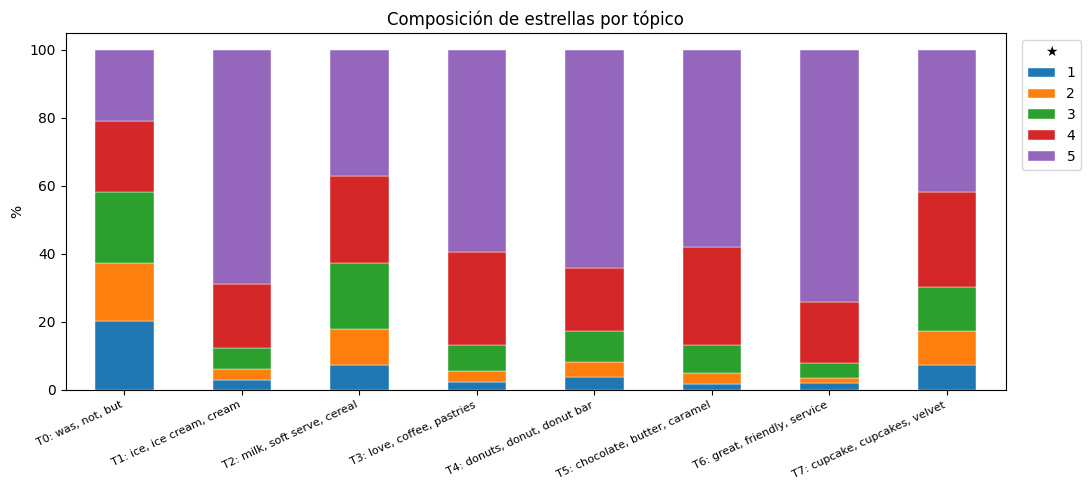

In [19]:
# --- NMF sobre TF-IDF: tópicos no supervisados, interpretables ---
N_TOPICS = 8
nmf = NMF(n_components=N_TOPICS, random_state=42, init="nndsvda", max_iter=400)
W = nmf.fit_transform(X_tfidf_ngram)     # documentos x tópicos
H = nmf.components_                       # tópicos x términos
 
terminos = tfidf_ngram_vec.get_feature_names_out()
print("Tópicos encontrados (top 10 términos c/u):\n")
topic_labels = []
for k in range(N_TOPICS):
    top_idx = H[k].argsort()[::-1][:10]
    palabras = [terminos[i] for i in top_idx]
    topic_labels.append(", ".join(palabras[:3]))
    print(f"Tópico {k} [{topic_labels[k]}]:")
    print(f"  {', '.join(palabras)}")
 
yelp_df["topico_dominante"] = W.argmax(axis=1)
 
# Cruce tópico x rating: qué tema predice mejor la insatisfacción
cruce = pd.crosstab(yelp_df["topico_dominante"], yelp_df["Rating"], normalize="index") * 100
cruce.index = [f"T{k}: {topic_labels[k]}" for k in cruce.index]
print("\nComposición de estrellas por tópico dominante (%):")
print(cruce.round(1).to_string())
 
fig, ax = plt.subplots(figsize=(11, 5))
cruce.plot(kind="bar", stacked=True, ax=ax, edgecolor="white", linewidth=.3)
ax.set_title("Composición de estrellas por tópico"); ax.set_ylabel("%")
ax.legend(title="★", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.xticks(rotation=25, ha="right", fontsize=8)
plt.tight_layout(); plt.show()

### Aspectos de la experiencia del cliente

Además de estudiar el sentimiento general, se identifican temas concretos de una visita a un restaurante: comida, servicio, precio, espera y ambiente. El diccionario permite una lectura rápida y transparente de qué reseñas mencionan cada aspecto.

La comparación entre reseñas que mencionan un aspecto y las que no lo mencionan muestra una diferencia descriptiva de rating. Un valor negativo sugiere que ese tema aparece con valoraciones medias más bajas, pero no demuestra que sea la causa de la insatisfacción. La cobertura indica qué parte del corpus queda representada por cada categoría; una cobertura baja limita la fuerza de cualquier conclusión.

El gráfico ordena los aspectos por esa diferencia para destacar posibles áreas de atención, mientras que los colores separan asociaciones positivas y negativas.


Cobertura de reseñas que mencionan cada aspecto:
comida      48.0
servicio    28.5
precio      20.0
espera      26.7
ambiente    14.0

Rating medio según se mencione el aspecto (ordenado por impacto):
 aspecto  rating_si_mencion  rating_no_mencion  diferencia
  precio              3.877              4.194      -0.317
  espera              4.009              4.175      -0.166
servicio              4.118              4.136      -0.018
  comida              4.165              4.099       0.067
ambiente              4.251              4.111       0.140


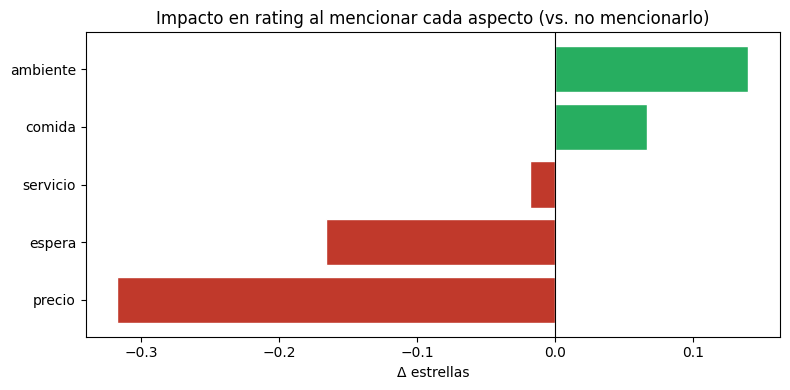


→ El aspecto con mayor Δ negativo es la palanca de negocio más clara:
  cuando aparece en la reseña, el rating cae más que con cualquier otro.


In [20]:
ASPECTOS = {
    "comida":   ["food", "dish", "flavor", "taste", "delicious", "menu", "portion",
                 "meal", "pizza", "burger", "sauce", "fresh", "cook", "chef"],
    "servicio": ["service", "staff", "waiter", "waitress", "server", "rude",
                 "friendly", "attentive", "manager", "host"],
    "precio":   ["price", "expensive", "cheap", "worth", "value", "cost", "overpriced",
                 "affordable"],
    "espera":   ["wait", "slow", "quick", "fast", "line", "reservation", "minutes",
                 "hour", "long"],
    "ambiente": ["ambiance", "atmosphere", "decor", "noisy", "cozy", "clean", "dirty",
                 "music", "seating", "crowded"],
}
 
def marcar_aspectos(tokens):
    presentes = set()
    tset = set(tokens)
    for aspecto, palabras in ASPECTOS.items():
        if tset & set(palabras):
            presentes.add(aspecto)
    return presentes
 
yelp_df["aspectos"] = yelp_df["tokens"].map(marcar_aspectos)
for aspecto in ASPECTOS:
    yelp_df[f"asp_{aspecto}"] = yelp_df["aspectos"].map(lambda s: aspecto in s)
 
cobertura_aspectos = {a: yelp_df[f"asp_{a}"].mean() for a in ASPECTOS}
print("\nCobertura de reseñas que mencionan cada aspecto:")
print(pd.Series(cobertura_aspectos).mul(100).round(1).to_string())
 
# Rating medio condicionado a mencionar (o no) cada aspecto
filas = []
for a in ASPECTOS:
    con = yelp_df.loc[yelp_df[f"asp_{a}"], "Rating"].mean()
    sin = yelp_df.loc[~yelp_df[f"asp_{a}"], "Rating"].mean()
    filas.append((a, con, sin, con - sin))
tabla_aspectos = pd.DataFrame(filas, columns=["aspecto", "rating_si_mencion",
                                               "rating_no_mencion", "diferencia"])
tabla_aspectos = tabla_aspectos.sort_values("diferencia")
print("\nRating medio según se mencione el aspecto (ordenado por impacto):")
print(tabla_aspectos.round(3).to_string(index=False))
 
fig, ax = plt.subplots(figsize=(8, 4))
colores = ["#c0392b" if v < 0 else "#27ae60" for v in tabla_aspectos["diferencia"]]
ax.barh(tabla_aspectos["aspecto"], tabla_aspectos["diferencia"], color=colores, edgecolor="white")
ax.axvline(0, color="black", lw=.8)
ax.set_title("Impacto en rating al mencionar cada aspecto (vs. no mencionarlo)")
ax.set_xlabel("Δ estrellas"); plt.tight_layout(); plt.show()
 
print("\n→ El aspecto con mayor Δ negativo es la palanca de negocio más clara:\n"
      "  cuando aparece en la reseña, el rating cae más que con cualquier otro.")

## 6. Lectura integrada y siguientes pasos

El notebook combina representaciones léxicas, sentimiento, similitud, tópicos y aspectos porque cada técnica responde a una pregunta distinta. TF-IDF y los n-gramas permiten comparar vocabulario; VADER ofrece una referencia rápida de polaridad; la similitud ayuda a localizar repetición y casos relacionados; NMF resume temas; y los aspectos conectan el texto con dimensiones concretas de la experiencia del cliente.

Los resultados deben interpretarse considerando tres límites. Primero, la distribución de ratings puede estar desbalanceada, por lo que una métrica global puede ocultar el comportamiento de las clases minoritarias. Segundo, las asociaciones entre palabras, tópicos, aspectos y estrellas no prueban causalidad. Tercero, varias señales dependen de reglas o diccionarios, así que conviene validar los casos relevantes mediante revisión manual o anotación.

Para continuar el proyecto, se pueden comparar modelos supervisados con distintas representaciones y evaluar su rendimiento con particiones estratificadas. Si se pretende medir generalización temporal o a restaurantes nuevos, la separación debe hacerse por fecha o por `rid`, evitando que reseñas muy parecidas aparezcan en entrenamiento y prueba.